# 手写数字识别：神经网络构建与超参数对比分析

本 Notebook 旨在使用 `sklearn` 的 `load_digits` 数据集构建多层感知机（MLP）分类器，并通过控制变量法，详细对比激活函数、优化算法、隐藏层结构以及学习率等超参数对神经网络预测准确率和收敛速度的影响。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体以支持图表显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

## 1. 数据集加载与可视化勘探
`load_digits` 包含 1797 个样本，每个样本是一个 8x8 的像素矩阵（展平后为 64 维特征向量），表示 0-9 的手写数字。

特征矩阵维度: (1797, 64)
标签向量维度: (1797,)



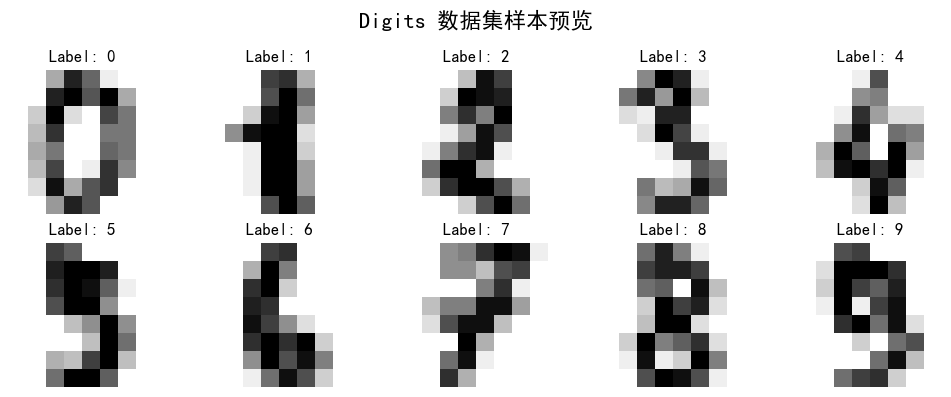

In [2]:
# 加载数据
digits = load_digits()
X = digits.data
y = digits.target

print(f"特征矩阵维度: {X.shape}")
print(f"标签向量维度: {y.shape}\n")

# 随机抽样展示部分手写数字
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(X[i].reshape(8, 8), cmap=plt.cm.gray_r, interpolation='nearest')
    ax.set_title(f"Label: {y[i]}")
    ax.axis('off')
plt.suptitle('Digits 数据集样本预览', fontsize=16)
plt.tight_layout()
plt.show()

## 2. 数据预处理
神经网络对输入特征的尺度非常敏感。如果特征未经过标准化，使用基于梯度的优化算法（如 SGD, Adam）时可能导致收敛极慢或陷入局部最优。因此，必须使用 `StandardScaler` 进行零均值单位方差归一化。

In [3]:
# 划分训练集与测试集 (80% 训练, 20% 测试)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 特征标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"训练集样本数: {X_train_scaled.shape[0]}")
print(f"测试集样本数: {X_test_scaled.shape[0]}")

训练集样本数: 1437
测试集样本数: 360


## 3. 基准模型构建与混淆矩阵分析
首先，我们构建一个单隐藏层（100个神经元）、使用 ReLU 激活函数和 Adam 优化器的基准模型，观察其性能。

基准模型预测准确率: 97.50%


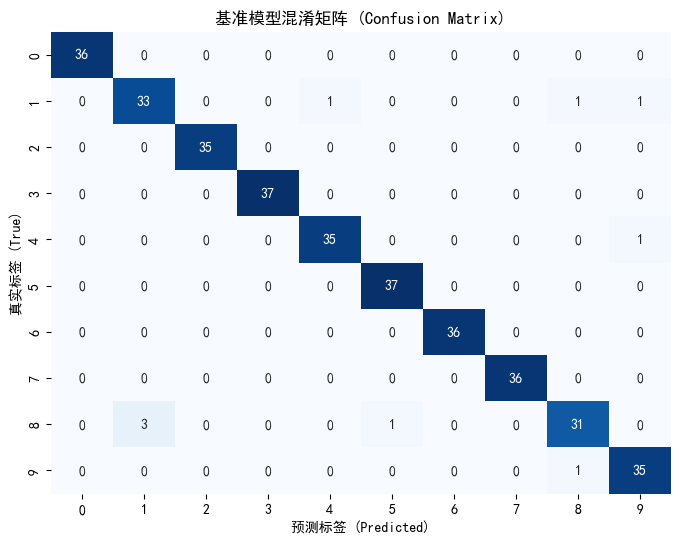

In [4]:
base_mlp = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam', 
                         max_iter=500, random_state=42)
base_mlp.fit(X_train_scaled, y_train)
y_pred_base = base_mlp.predict(X_test_scaled)
base_acc = accuracy_score(y_test, y_pred_base)

print(f"基准模型预测准确率: {base_acc * 100:.2f}%")

# 绘制混淆矩阵
cm = confusion_matrix(y_test, y_pred_base)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('预测标签 (Predicted)')
plt.ylabel('真实标签 (True)')
plt.title('基准模型混淆矩阵 (Confusion Matrix)')
plt.show()

## 4. 超参数对比实验
接下来，我们将系统性地改变不同的超参数，并记录其在测试集上的准确率以及训练过程中的 Loss 变化。

### 实验一：激活函数与优化算法的交叉对比
* **激活函数 (Activation)**：`logistic` (Sigmoid), `tanh`, `relu`
* **优化算法 (Solver)**：`sgd` (随机梯度下降), `adam` (自适应矩估计)

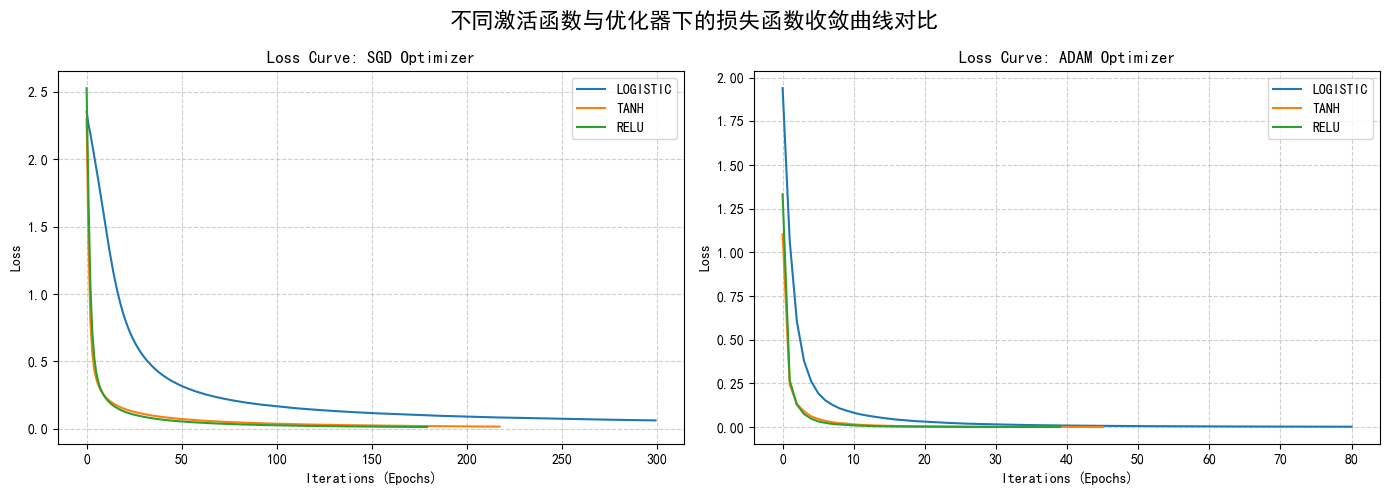

Activation,logistic,relu,tanh
Solver,,,
adam,0.977778,0.975,0.980556
sgd,0.966667,0.975,0.972222


In [5]:
activations = ['logistic', 'tanh', 'relu']
solvers = ['sgd', 'adam']

results = []
loss_curves = {}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for solver in solvers:
    for activation in activations:
        # 构建模型
        mlp = MLPClassifier(hidden_layer_sizes=(100,), activation=activation, solver=solver, 
                            learning_rate_init=0.01, max_iter=300, random_state=42)
        mlp.fit(X_train_scaled, y_train)
        acc = accuracy_score(y_test, mlp.predict(X_test_scaled))
        
        # 记录结果
        name = f"{solver.upper()} + {activation.upper()}"
        results.append({'Solver': solver, 'Activation': activation, 'Accuracy': acc})
        loss_curves[name] = mlp.loss_curve_
        
        # 绘制 Loss 曲线 (按 Solver 分图)
        ax_idx = 0 if solver == 'sgd' else 1
        axes[ax_idx].plot(mlp.loss_curve_, label=activation.upper())

axes[0].set_title('Loss Curve: SGD Optimizer')
axes[0].set_xlabel('Iterations (Epochs)')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].set_title('Loss Curve: ADAM Optimizer')
axes[1].set_xlabel('Iterations (Epochs)')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.suptitle('不同激活函数与优化器下的损失函数收敛曲线对比', fontsize=16)
plt.tight_layout()
plt.show()

# 打印准确率结果
df_results = pd.DataFrame(results)
display(df_results.pivot(index='Solver', columns='Activation', values='Accuracy'))

**结果分析 1 (收敛与激活函数)：**
1. **SGD vs Adam**：在相同的迭代次数内，`Adam` 的 Loss 下降速度远快于 `SGD`，且最终收敛的 Loss 值更低。这体现了 Adam 利用一阶矩和二阶矩自适应调整学习率的优势。
2. **ReLU vs Logistic/Tanh**：从曲线可以看出，`ReLU` 收敛最快，`Tanh` 次之，`Logistic` (Sigmoid) 最慢。这是由于 Sigmoid 函数在两侧存在严重的**梯度消失（Vanishing Gradient）**问题，导致参数更新极其缓慢。而 ReLU 在 $x>0$ 时梯度恒为 1，有效缓解了该问题。

### 实验二：网络深度与宽度的影响 (隐藏层结构)
固定激活函数为 ReLU，优化器为 Adam。我们对比浅层宽网络和深层窄网络的分类表现。

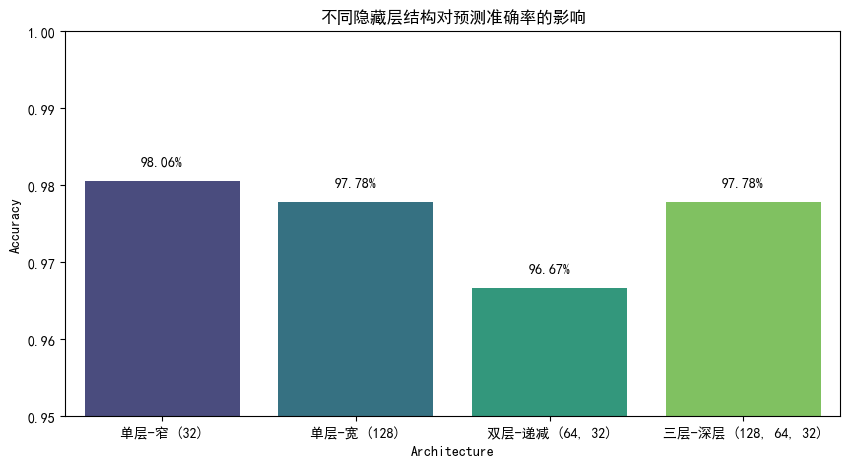

In [6]:
architectures = [
    {'name': '单层-窄 (32)', 'layers': (32,)},
    {'name': '单层-宽 (128)', 'layers': (128,)},
    {'name': '双层-递减 (64, 32)', 'layers': (64, 32)},
    {'name': '三层-深层 (128, 64, 32)', 'layers': (128, 64, 32)}
]

arch_results = []

for arch in architectures:
    mlp_arch = MLPClassifier(hidden_layer_sizes=arch['layers'], activation='relu', solver='adam', 
                             max_iter=500, random_state=42)
    mlp_arch.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, mlp_arch.predict(X_test_scaled))
    arch_results.append({'Architecture': arch['name'], 'Accuracy': acc})

df_arch = pd.DataFrame(arch_results)

plt.figure(figsize=(10, 5))
sns.barplot(x='Architecture', y='Accuracy', data=df_arch, palette='viridis')
plt.title('不同隐藏层结构对预测准确率的影响')
plt.ylim(0.95, 1.0) # 放大差异
for i, v in enumerate(df_arch['Accuracy']):
    plt.text(i, v + 0.002, f"{v*100:.2f}%", ha='center', fontweight='bold')
plt.show()

**结果分析 2 (网络拓扑结构)：**
1. **宽度增加**：对比 `(32,)` 和 `(128,)`，单层神经元数量增加提升了模型的表达能力，准确率有所上升。
2. **深度增加**：增加层数 `(64, 32)` 或 `(128, 64, 32)` 能够让模型学习到更抽象的高维非线性特征。在这个相对简单的数字识别任务中，双层结构表现最优。但过深的网络（如三层结构）在数据量有限的情况下，反而可能因为**过拟合（Overfitting）**导致测试集准确率略微下降。

### 最终综合结论
对于类似的表格型或低维图像分类任务，构建神经网络的最佳实践通常是：**首选 ReLU 激活函数与 Adam 优化器，并使用 1 到 2 层的金字塔状递减隐藏层结构。** 且必须在训练前对输入特征进行标准化处理。